
# 2 &mdash; What a covariance target can do that an $S$ target cannot

* **B.3** directional squeezed source &mdash; asymmetry *between* the port blocks
  at finite cooperativity, enforced together with a transmission pin so the
  minimal device stays connected (Sec. 11).
* **B.4** broadband squeezer &mdash; point + $\Omega$-derivative pins; the decay
  ratios $\tilde\kappa_i$ are what flattens the band (App. A.4(c)).

Script version: `examples/02_directional_and_spectral.py`.

In [1]:
# In case you are using Google Colab, this cell installs AutoGaussian
import sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install "git+https://github.com/Fouriersaur/AutoGaussian.git#subdirectory=autogaussian"
    !pip install cvxpy    # optional: infeasibility certificates (Sec. 6)
else:
    # running from a clone: put the package root on sys.path
    import os
    sys.path.insert(0, os.path.abspath(os.getcwd()))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from autogaussian import CovarianceArchitectureOptimizer, variance_to_dB
from autogaussian.gallery import broadband_squeezer, directional_squeezed_source


## B.3 &mdash; directional squeezed source

How many auxiliary modes are needed? Sec. 6(a): grow the auxiliary count until
the fully connected graph works. Two directly coupled modes cannot be made
directional by any coupling phase alone (mode-swap symmetry), so 0 auxiliaries
**must** fail here.

In [3]:
problem = directional_squeezed_source(variance=0.2, forward_transmission=1.3,
                                      isolate_backward=True)

optimizer = None
for num_auxiliary_modes in (0, 1):
    candidate = CovarianceArchitectureOptimizer(
        problem.target, num_auxiliary_modes=num_auxiliary_modes, seed=3,
        make_initial_test=False, kwargs_optimization={"num_tests": 30},
        **problem.optimizer_kwargs())
    success, infos = candidate.test_graph(candidate.space.fully_connected())
    print("  %i auxiliary modes: %-8s best loss %.2g"
          % (num_auxiliary_modes, "VALID" if success else "INVALID",
             min(info["loss_reached"] for info in infos)))
    if success:
        optimizer = candidate
        break

  0 auxiliary modes: INVALID  best loss 0.27


  1 auxiliary modes: VALID    best loss 9.5e-11


In [4]:
x = infos[-1]["x"]
V = np.real(optimizer.oracle.covariance(x, 0.0))
S, _ = optimizer.oracle.scattering(x, 0.0)

print("port covariance at Omega = 0:")
print(np.round(V, 4))
print("\nport 1 (vacuum target): diag = %.4f, %.4f" % (V[0, 0], V[1, 1]))
print("port 2 squeezing:       %.2f dB  (variance %.4f)"
      % (variance_to_dB(V[2, 2]), V[2, 2]))
print("transport: forward |S_10|^2 = %.3f, backward |S_01|^2 = %.3f"
      % (abs(S[1, 0]) ** 2, abs(S[0, 1]) ** 2))
print("stability margin: max Re eig(M~) = %.3f" % infos[-1]["max_real_eigenvalue"])

port covariance at Omega = 0:
[[ 1.0e+00  0.0e+00 -1.2e-03  2.6e-03]
 [ 0.0e+00  1.0e+00  5.0e-04  5.9e-03]
 [-1.2e-03  5.0e-04  2.0e-01  0.0e+00]
 [ 2.6e-03  5.9e-03  0.0e+00  5.0e+00]]

port 1 (vacuum target): diag = 1.0000, 1.0000
port 2 squeezing:       6.99 dB  (variance 0.2000)
transport: forward |S_10|^2 = 1.300, backward |S_01|^2 = 0.000
stability margin: max Re eig(M~) = -0.011



## B.4 &mdash; broadband squeezer

$\sigma_{xx} = 0.5$, flat across $|\Omega| \le 0.5$.

Derivative pins alone only constrain the spectrum *at* $\Omega = 0$ &mdash; the
optimiser can satisfy them by shrinking $\tilde\kappa$ instead of widening the
band, so the band itself is pinned as well.

In [5]:
bandwidth = 0.5
problem = broadband_squeezer(variance=0.5, num_derivatives=2, bandwidth=bandwidth)
print(problem.target)

optimizer_bb = CovarianceArchitectureOptimizer(
    problem.target, num_auxiliary_modes=1, seed=1, make_initial_test=False,
    kwargs_optimization={"num_tests": 25}, **problem.optimizer_kwargs())
success, infos_bb = optimizer_bb.test_graph(optimizer_bb.space.fully_connected())
print("fully connected graph:", "VALID" if success else "INVALID",
      " loss %.2g" % infos_bb[-1]["loss_reached"])

CovarianceTarget(broadband squeezer, 1 ports, 7 pins)
  sigma_out[0,0](Omega=0) = 0.5   (w=1, full)
  d^1/dOmega^1 sigma_out[0,0](Omega=0) = 0.0   (w=1, full)
  d^2/dOmega^2 sigma_out[0,0](Omega=0) = 0.0   (w=1, full)
  sigma_out[0,0](Omega=-0.5) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=-0.25) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=0.25) = (0.5+0j)   (w=1, full)
  sigma_out[0,0](Omega=0.5) = (0.5+0j)   (w=1, full)


fully connected graph: VALID  loss 8.5e-11


decay ratios found: {'kappa~_0': 23.692541137430503, 'kappa~_1': 1.3697048273527166}


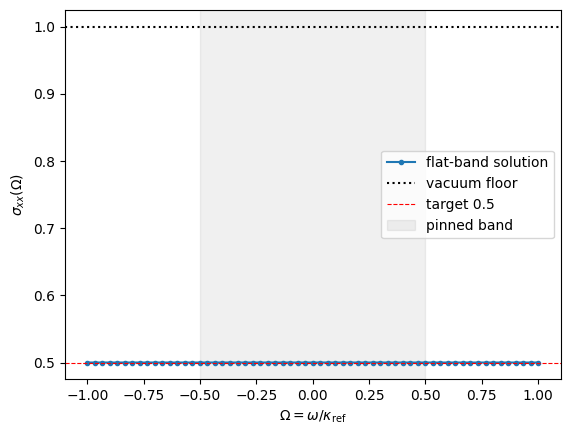

In [6]:
x_bb = infos_bb[-1]["x"]
omegas = np.linspace(-1.0, 1.0, 61)
spectrum = np.array([np.real(optimizer_bb.oracle.covariance(x_bb, w)[0, 0])
                     for w in omegas])

print("decay ratios found:", optimizer_bb.param.physical_report(x_bb)["decay_ratios"])

plt.plot(omegas, spectrum, "o-", ms=3, label="flat-band solution")
plt.axhline(1.0, color="k", ls=":", label="vacuum floor")
plt.axhline(0.5, color="r", ls="--", lw=0.8, label="target 0.5")
plt.axvspan(-bandwidth, bandwidth, color="k", alpha=0.06, label="pinned band")
plt.xlabel(r"$\Omega = \omega/\kappa_{\rm ref}$")
plt.ylabel(r"$\sigma_{xx}(\Omega)$")
plt.legend()
plt.show()